In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from pydub import AudioSegment
import io

In [5]:
RAW_AUDIO_DIR = Path("../raw_audio")
DATA_DIR = Path("../data")
TRUTH_DIR = DATA_DIR / "truth"
LIE_DIR = DATA_DIR / "lie"

TRUTH_DIR.mkdir(parents=True, exist_ok=True)
LIE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_RATE = 22050
N_MELS = 128
HOP_LENGTH = 512

In [6]:
def audio_to_mel_spectrogram(audio_path, save_path):
    try:
        # Convert m4a to wav in memory using pydub
        audio_path = str(audio_path)
        audio = AudioSegment.from_file(audio_path)
        
        # Export to wav bytes in memory
        wav_io = io.BytesIO()
        audio.export(wav_io, format="wav")
        wav_io.seek(0)
        
        # Load with librosa from the in-memory wav
        y, sr = librosa.load(wav_io, sr=SAMPLE_RATE)
        
        # Generate mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Save as image
        fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100)
        librosa.display.specshow(mel_spec_db, sr=sr, hop_length=HOP_LENGTH, ax=ax)
        ax.set_axis_off()
        plt.tight_layout(pad=0)
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
        plt.close()
        
        print(f"Saved: {save_path}")
        return True
        
    except Exception as e:
        print(f"Error on {audio_path}: {e}")
        return False

In [7]:
# Process all truth files
truth_files = list(RAW_AUDIO_DIR.glob("Truth_*.m4a")) + \
              list(RAW_AUDIO_DIR.glob("Truth_*.wav")) + \
              list(RAW_AUDIO_DIR.glob("Truth_*.mp3"))

print(f"Found {len(truth_files)} truth files")

for i, audio_file in enumerate(truth_files):
    save_path = TRUTH_DIR / f"truth_{i+1:02d}.png"
    audio_to_mel_spectrogram(audio_file, save_path)

# Process all lie files
lie_files = list(RAW_AUDIO_DIR.glob("Lie_*.m4a")) + \
            list(RAW_AUDIO_DIR.glob("Lie_*.wav")) + \
            list(RAW_AUDIO_DIR.glob("Lie_*.mp3"))

print(f"\nFound {len(lie_files)} lie files")

for i, audio_file in enumerate(lie_files):
    save_path = LIE_DIR / f"lie_{i+1:02d}.png"
    audio_to_mel_spectrogram(audio_file, save_path)

print(f"\nDone. data/truth/ has {len(list(TRUTH_DIR.glob('*.png')))} images")
print(f"data/lie/ has {len(list(LIE_DIR.glob('*.png')))} images")

Found 10 truth files


c:\Users\PRAGADESH\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saved: ..\data\truth\truth_01.png
Saved: ..\data\truth\truth_02.png
Saved: ..\data\truth\truth_03.png
Saved: ..\data\truth\truth_04.png
Saved: ..\data\truth\truth_05.png
Saved: ..\data\truth\truth_06.png
Saved: ..\data\truth\truth_07.png
Saved: ..\data\truth\truth_08.png
Saved: ..\data\truth\truth_09.png
Saved: ..\data\truth\truth_10.png

Found 10 lie files
Saved: ..\data\lie\lie_01.png
Saved: ..\data\lie\lie_02.png
Saved: ..\data\lie\lie_03.png
Saved: ..\data\lie\lie_04.png
Saved: ..\data\lie\lie_05.png
Saved: ..\data\lie\lie_06.png
Saved: ..\data\lie\lie_07.png
Saved: ..\data\lie\lie_08.png
Saved: ..\data\lie\lie_09.png
Saved: ..\data\lie\lie_10.png

Done. data/truth/ has 10 images
data/lie/ has 10 images


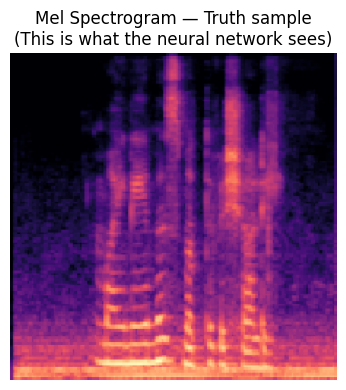

Image shape: (224, 224, 4)
Each pixel = a frequency + time combination
Brighter = louder at that frequency at that moment
This is your input data — the neural network will learn patterns in these images


In [8]:
# Load and display one truth spectrogram
sample_path = list(TRUTH_DIR.glob("*.png"))[0]
img = plt.imread(str(sample_path))

plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.title("Mel Spectrogram — Truth sample\n(This is what the neural network sees)")
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {img.shape}")
print("Each pixel = a frequency + time combination")
print("Brighter = louder at that frequency at that moment")
print("This is your input data — the neural network will learn patterns in these images")